In [2]:
import os
import pandas as pd
from datetime import datetime
import importlib
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

In [3]:
# Relative imports
d = os.path.abspath(os.getcwd())
os.chdir("../..")
import hidden_state_model.processor
importlib.reload(hidden_state_model.processor)
Processor = hidden_state_model.processor.Processor
os.chdir(d)

### Read (and compact) dataframes

In [4]:
compact = True

In [5]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
data_dir = os.path.join(d, "..", "data")
for file in os.listdir(data_dir):
    fname = os.path.join(data_dir, file)
    if file.endswith(".parquet"):
        read.append(file)
        print(f"Reading {file}")
        df = pd.read_parquet(fname)
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(fname, index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs)

if compact and len(dfs) > 10:
    print("Compacintg dfs")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(os.path.join(data_dir, f"combined_{timestamp}.parquet"))

    # Move files already in trash to trash within trash
    trash = os.path.join(data_dir, "trash")
    trash_in_trash = os.path.join(trash, f"trash_{timestamp}")
    os.makedirs(trash_in_trash, exist_ok=True)
    for f in os.listdir(trash):
        if f.endswith(".parquet") or f.endswith(".csv"):
            os.rename(os.path.join(trash, f), os.path.join(trash_in_trash, f))
    
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    for f in read:
        os.rename(os.path.join(data_dir, f), os.path.join(trash, f))

dfs = []  # Clear memory
raw_df

Reading combined_20240906175220.parquet
Reading 2024-09-07_11-31-19.parquet


,prev_entry,public_cards,player_piles,current_player_i,bet_in_stage,bet_in_game,player_has_played,player_is_folded,first_better_i,big_blind,...,player_type,opponent_names,action,amount,p,relative_ev,rank,tiebreakers,hand_index,state_id
state_id,,,,,,,,,,,,,,,,,,,,,
cc2a3234-bfcd-4e2b-8bdb-686215485494,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],call,2,0.4942,0.014826,0,"[9, 1, 0, 0, 0]",643.0,NaN
4d01fa55-3b5d-4bff-9405-f6d662314da4,cc2a3234-bfcd-4e2b-8bdb-686215485494,"[28, 2, 3]","[96, 96]",0,"[0, 0]","[4, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],check,0,0.3689,0.014756,1,"[2, 9, 3, 1, 0]",643.0,NaN
71edc4a8-d3e2-4dc1-b144-9f3364276d5a,4d01fa55-3b5d-4bff-9405-f6d662314da4,"[28, 2, 3, 37]","[96, 96]",0,"[0, 0]","[4, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],check,0,0.3770,0.015080,1,"[2, 11, 9, 3, 0]",643.0,NaN
664036cc-7bfe-4909-bafe-3cf4d2a315fb,71edc4a8-d3e2-4dc1-b144-9f3364276d5a,"[28, 2, 3, 37, 25]","[96, 96]",0,"[0, 0]","[4, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],check,0,0.4181,0.016724,1,"[2, 12, 11, 9, 0]",643.0,NaN
89023332-7a45-4a9a-bc67-aa216902ad1d,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],call,2,0.5425,0.016275,0,"[9, 4, 0, 0, 0]",202.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ea141c2c-500c-4145-813a-0bdfd40e9c82,98899fe5-2486-4c8e-8959-186708300ef2,"[33, 32, 23]","[70, 110]",0,"[0, 0]","[10, 10]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],check,0,0.4805,0.048050,0,"[10, 9, 7, 6, 0]",1022.0,NaN
79a32454-85ab-4bfa-ac7e-babc0b19cfa9,ea141c2c-500c-4145-813a-0bdfd40e9c82,"[33, 32, 23, 34]","[70, 110]",0,"[0, 0]","[10, 10]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],raise,7,0.8823,0.088230,4,"[10, 0, 0, 0, 0]",1022.0,NaN
9ed61a5d-22bd-4273-bbe0-16aa35b2e38f,79a32454-85ab-4bfa-ac7e-babc0b19cfa9,"[33, 32, 23, 34]","[63, 93]",0,"[7, 17]","[17, 27]","[True, True]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],raise,40,0.8823,0.194106,4,"[10, 0, 0, 0, 0]",1022.0,NaN


In [6]:
raw_df.dtypes

prev_entry            object
public_cards          object
player_piles          object
current_player_i       int64
bet_in_stage          object
bet_in_game           object
player_has_played     object
player_is_folded      object
first_better_i         int64
big_blind              int64
player_name           object
player_type           object
opponent_names        object
action                object
amount                 int64
p                    float64
relative_ev          float64
rank                   int64
tiebreakers           object
hand_index           float64
state_id             float64
dtype: object

In [7]:
# Check for conflicting rows
dupe_df = raw_df[raw_df.index.duplicated()]
assert len(dupe_df) == 0, dupe_df

## Process data

In [8]:
processor = Processor(raw_df)
df = processor.get_processed_df()
df

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,game_id,action,amount,excess_rank,p,relative_ev,stage,player_name,opponent_name,n_players
6266176704,0,0,0,0,0,0,0,0,0,0,...,fc33c5c1-cb77-4c66-ab30-1bc5eaa7f38b,fold,0,0,0.45151,0.013545,preflop,Arin Bavian,,2
10920399872,0,0,0,0,0,0,0,0,0,0,...,436ea57b-3449-4d1a-891b-4617f9bf07ee,raise,9,0,0.62710,0.018813,preflop,Arin,,2
6075844208,0,0,0,0,0,0,0,0,0,0,...,7f664572-dc02-4473-b3b6-15e7400915d1,call,2,0,0.57620,0.017286,preflop,Alun,,2
6166295648,0,0,0,0,0,0,0,0,0,0,...,4736ad1d-85ee-4ceb-a7a0-a52ea5016900,check,0,0,0.64511,0.025804,preflop,Arin,,2
f9e9cabb-4a45-4c4c-92af-b370c475d9ad,0,0,0,0,0,0,0,0,0,0,...,54f0e620-1125-4388-a45b-67127e58e74a,call,2,0,0.34010,0.010203,preflop,Tord,Max Mekker,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6162005392,0,36,0,0,0,7,0,0,0,0,...,62587ce9-080a-49b2-aa9a-c82158c51896,check,0,2,0.91260,0.410670,river,Arin,,2
10963606496,0,0,72,0,0,4,5,0,0,0,...,212448fc-9e6d-44e6-8c65-777e666419c5,raise,10,2,0.85510,0.752488,turn,Arin,,2
6165583184,0,69,0,0,0,6,13,0,0,0,...,3a3f521f-18e2-4b7e-bd37-29991c24e173,check,0,2,0.90150,0.811350,river,Arin,,2
6172461376,0,0,82,0,0,4,5,0,0,0,...,212448fc-9e6d-44e6-8c65-777e666419c5,check,0,1,0.61730,0.586435,river,Arin,,2


In [9]:
df.dtypes

raise_preflop                int64
raise_flop                   int64
raise_turn                   int64
raise_river                  int64
raise_showdown               int64
call_preflop                 int64
call_flop                    int64
call_turn                    int64
call_river                   int64
call_showdown                int64
check_preflop                int64
check_flop                   int64
check_turn                   int64
check_river                  int64
check_showdown               int64
opponent_raise_preflop       int64
opponent_raise_flop          int64
opponent_raise_turn          int64
opponent_raise_river         int64
opponent_raise_showdown      int64
opponent_call_preflop        int64
opponent_call_flop           int64
opponent_call_turn           int64
opponent_call_river          int64
opponent_call_showdown       int64
opponent_check_preflop       int64
opponent_check_flop          int64
opponent_check_turn          int64
opponent_check_river

## Training

In [10]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error

In [11]:
X = df.drop(["excess_rank", "game_id", "p", "relative_ev"], axis=1)
y = df["p"]
groups = df["game_id"]  # Group by 'game_id' to ensure no data leakage

In [12]:
X

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,opponent_check_flop,opponent_check_turn,opponent_check_river,opponent_check_showdown,action,amount,stage,player_name,opponent_name,n_players
6266176704,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,fold,0,preflop,Arin Bavian,,2
10920399872,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,raise,9,preflop,Arin,,2
6075844208,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,call,2,preflop,Alun,,2
6166295648,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,check,0,preflop,Arin,,2
f9e9cabb-4a45-4c4c-92af-b370c475d9ad,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,call,2,preflop,Tord,Max Mekker,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6162005392,0,36,0,0,0,7,0,0,0,0,...,1,1,0,0,check,0,river,Arin,,2
10963606496,0,0,72,0,0,4,5,0,0,0,...,0,0,0,0,raise,10,turn,Arin,,2
6165583184,0,69,0,0,0,6,13,0,0,0,...,1,2,0,0,check,0,river,Arin,,2
6172461376,0,0,82,0,0,4,5,0,0,0,...,0,0,0,0,check,0,river,Arin,,2


In [13]:
y

6266176704                              0.45151
10920399872                             0.62710
6075844208                              0.57620
6166295648                              0.64511
f9e9cabb-4a45-4c4c-92af-b370c475d9ad    0.34010
                                         ...   
6162005392                              0.91260
10963606496                             0.85510
6165583184                              0.90150
6172461376                              0.61730
6182257328                              0.79070
Name: p, Length: 5035, dtype: float64

In [14]:
# Identify categorical columns (excluding 'game_id')
categorical_cols = ["action", "stage", "player_name", "opponent_name"]

# Preprocessing pipeline: OneHotEncoding for categorical and scaling for numerical
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), categorical_cols)],
    remainder="passthrough",
)

# Create the full pipeline with logistic regression
model = Pipeline(
    [
        ("preprocess", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

In [15]:
# Grouped train-test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (4004, 36)
Test shape: (1031, 36)


In [16]:
# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage',
                                                   'player_name',
                                                   'opponent_name'])])),
                ('regressor', LinearRegression())])

In [17]:
# Get predictions
y_pred = model.predict(X_test)
pred_df = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE: {mae}")
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE: {mape*100:.2f}%")
pred_df

RMSE: 0.16689215661758008
MAE: 0.12955482783363062
MAPE: 32.90%


,y_test,y_pred
6166295648,0.64511,0.488401
6179041824,0.57620,0.488401
6076151888,0.42610,0.495875
0e799b3a-37a5-4c83-a0d5-ae054ffb39b5,0.60860,0.636344
6073437488,0.47110,0.445187
...,...,...
6118363824,0.39580,0.407949
6165562320,0.77300,0.759600
6165381232,0.83030,0.591514
6162005392,0.91260,0.551038


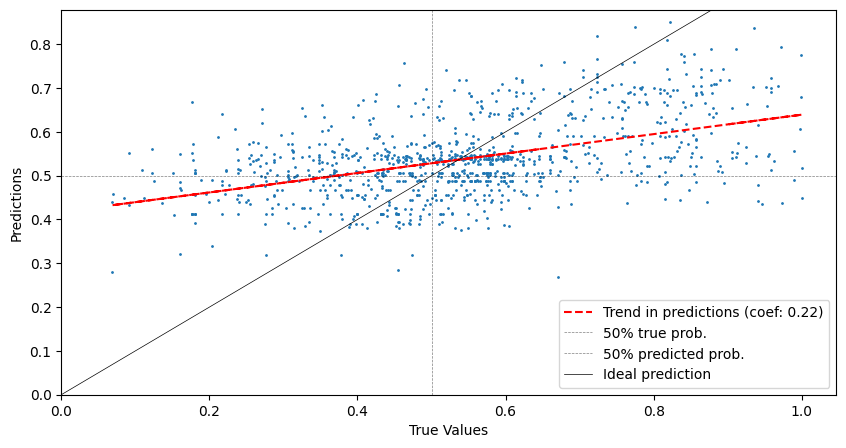

In [18]:
# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(y_test, y_pred, s=1)
# Plot a trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "r--", label=f"Trend in predictions (coef: {z[0]:.2f})")
plt.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% true prob.")
plt.axhline(y=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% predicted prob.")
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100], color="black", linewidth=0.5, label="Ideal prediction")
plt.legend()
plt.show()

### Examine feature importance

In [19]:
# Calculate feature importance
# Get the one-hot encoded feature names
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
feature_names = ohe.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([feature_names, X.columns[len(categorical_cols):]])

coefs = model.named_steps["regressor"].coef_

# Sort by absolute value
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)
coef_df

,feature,coef,abs_coef
13,call_preflop,6.774736e+10,6.774736e+10
33,opponent_check_preflop,-6.774736e+10,6.774736e+10
32,opponent_call_showdown,3.651552e+10,3.651552e+10
12,raise_showdown,-3.651552e+10,3.651552e+10
16,call_river,-1.649446e+08,1.649446e+08
22,check_showdown,1.373838e+08,1.373838e+08
37,opponent_check_showdown,-1.373838e+08,1.373838e+08
15,call_turn,1.109830e+08,1.109830e+08
35,opponent_check_turn,-1.109830e+08,1.109830e+08
14,call_flop,1.086897e+08,1.086897e+08


### Compare to XGBoost

In [33]:
from xgboost import XGBRegressor

# Create the full pipeline with XGBoost
model = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "regressor",
            XGBRegressor(
                n_estimators=100,
                objective="reg:squarederror",
                learning_rate=0.01,
                max_depth=3,
                reg_alpha=1,
                reg_lambda=1,
            ),
        ),
    ]
)

In [36]:
# Cross validate to find good hyperparameters
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'regressor__n_estimators': [100, 500],
    'regressor__learning_rate': [0.01, 0.1],
    'regressor__max_depth': [3, 5, 7],
    'regressor__subsample': [0.6, 0.8, 1.0],
    'regressor__colsample_bytree': [0.6, 0.8, 1.0],
}

# Grid search over the XGBRegressor parameters
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters and score
print(grid_search.best_params_)
print(grid_search.best_score_)

{'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 500, 'regressor__subsample': 1.0}
-0.024511265333896887


In [37]:
# Use the best model
model = grid_search.best_estimator_

In [38]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage',
                                                   'player_name',
                                                   'opponent_name'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rounds=None,
                              e...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

In [39]:
# Get predictions
y_pred = model.predict(X_test)
pred_df = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE: {mae}")
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE: {mape*100:.2f}%")
pred_df

RMSE: 0.16494995638010293
MAE: 0.12405116315551687
MAPE: 31.30%


,y_test,y_pred
6166295648,0.64511,0.527100
6179041824,0.57620,0.527100
6076151888,0.42610,0.501961
0e799b3a-37a5-4c83-a0d5-ae054ffb39b5,0.60860,0.579739
6073437488,0.47110,0.484079
...,...,...
6118363824,0.39580,0.192199
6165562320,0.77300,0.645356
6165381232,0.83030,0.562142
6162005392,0.91260,0.555596
